## Lab-6: Distance-Based Classification and K-Nearest Neighbors

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(42)
n1 = 100
n2 = 100

mean1 = np.array([-1.5, -1])
mean2 = np.array([1.5, 1])
mat_eye = np.eye(2)

x1 = np.random.multivariate_normal(mean1, mat_eye, n1)
x2 = np.random.multivariate_normal(mean2, mat_eye, n2)

y1 = np.zeros(n1)
y2 = np.ones(n2)
X = np.vstack((x1, x2))
y = np.concatenate((y1, y2))
print(X)
print(f"Tracking - X shape: {X.shape}, y shape: {y.shape}")

[[-1.00328585e+00 -1.13826430e+00]
 [-8.52311462e-01  5.23029856e-01]
 [-1.73415337e+00 -1.23413696e+00]
 [ 7.92128155e-02 -2.32565271e-01]
 [-1.96947439e+00 -4.57439956e-01]
 [-1.96341769e+00 -1.46572975e+00]
 [-1.25803773e+00 -2.91328024e+00]
 [-3.22491783e+00 -1.56228753e+00]
 [-2.51283112e+00 -6.85752667e-01]
 [-2.40802408e+00 -2.41230370e+00]
 [-3.43512311e-02 -1.22577630e+00]
 [-1.43247180e+00 -2.42474819e+00]
 [-2.04438272e+00 -8.89077410e-01]
 [-2.65099358e+00 -6.24301982e-01]
 [-2.10063869e+00 -1.29169375e+00]
 [-2.10170661e+00  8.52278185e-01]
 [-1.51349722e+00 -2.05771093e+00]
 [-6.77455088e-01 -2.22084365e+00]
 [-1.29113640e+00 -2.95967012e+00]
 [-2.82818605e+00 -8.03138764e-01]
 [-7.61533420e-01 -8.28631719e-01]
 [-1.61564828e+00 -1.30110370e+00]
 [-2.97852199e+00 -1.71984421e+00]
 [-1.96063877e+00  5.71222262e-02]
 [-1.15638171e+00 -2.76304016e+00]
 [-1.17591603e+00 -1.38508228e+00]
 [-2.17692200e+00 -3.88323711e-01]
 [-4.69000478e-01 -6.87198809e-02]
 [-2.33921752e+00 -1

In [2]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print(f"Tracking - x_train shape: {x_train.shape}")
print(f"Tracking - x_test shape: {x_test.shape}")
print(f"Tracking - y_train shape: {y_train.shape}")
print(f"Tracking - y_test shape: {y_test.shape}")

Tracking - x_train shape: (140, 2)
Tracking - x_test shape: (60, 2)
Tracking - y_train shape: (140,)
Tracking - y_test shape: (60,)


In [3]:
mean1_est = np.mean(x_train[y_train == 0], axis=0)
mean2_est = np.mean(x_train[y_train == 1], axis=0)

print(f"Tracking - Estimated Mean 1: {mean1_est}")
print(f"Tracking - Estimated Mean 2: {mean2_est}")

Tracking - Estimated Mean 1: [-1.54734039 -0.93615747]
Tracking - Estimated Mean 2: [1.61918651 1.01275567]


In [4]:
def euclidean_distance(x, mu):
    return np.sqrt(np.sum((x - mu)**2))

y_pred = []

for point in x_test:
    dist_to_mean1 = euclidean_distance(point, mean1_est)
    dist_to_mean2 = euclidean_distance(point, mean2_est)
    
    # Assign to class with minimum distance
    if dist_to_mean1 < dist_to_mean2:
        y_pred.append(0)
    else:
        y_pred.append(1)

y_pred = np.array(y_pred)

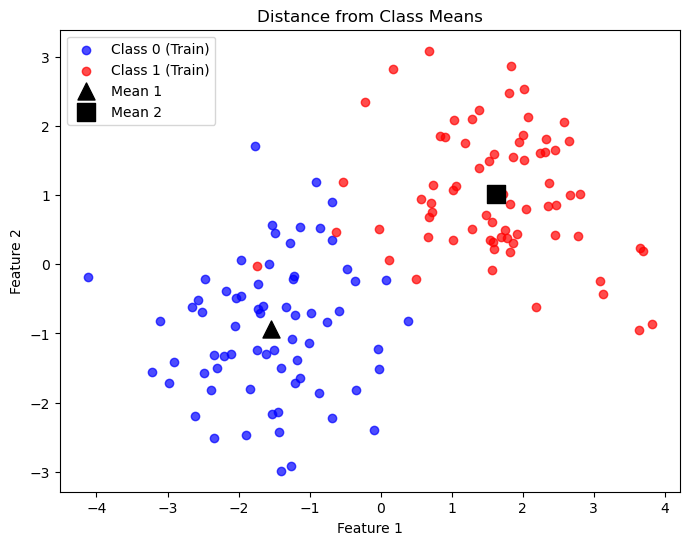

In [5]:
plt.figure(figsize=(8, 6))

# Plot training points with muted, sober colors
plt.scatter(x_train[y_train == 0][:, 0], x_train[y_train == 0][:, 1], 
            color='blue', label='Class 0 (Train)', alpha=0.7)
plt.scatter(x_train[y_train == 1][:, 0], x_train[y_train == 1][:, 1], 
            color='red', label='Class 1 (Train)', alpha=0.7)

plt.scatter(mean1_est[0], mean1_est[1], 
            color='black', marker='^', s=150, label='Mean 1')
plt.scatter(mean2_est[0], mean2_est[1], 
            color='black', marker='s', s=150, label='Mean 2')

plt.title('Distance from Class Means')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

plt.show()

## Task 2: K-Nearest Neighbors Classification

K-NN Classification Accuracies:
K =  1 | Accuracy = 98.33%
K =  3 | Accuracy = 98.33%
K =  5 | Accuracy = 98.33%
K = 11 | Accuracy = 98.33%
K = 21 | Accuracy = 96.67%


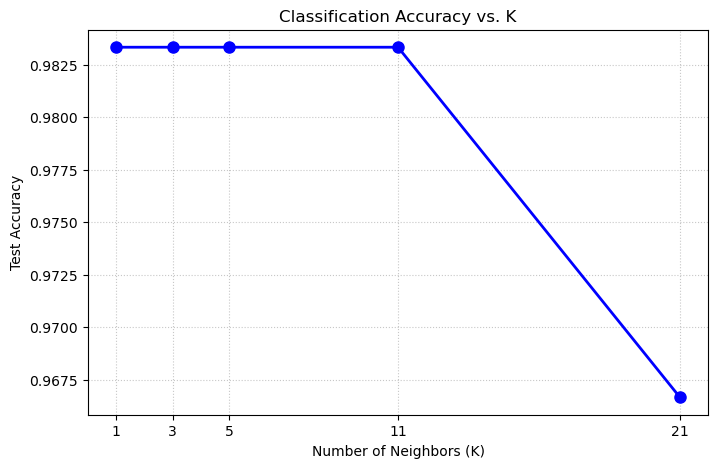

In [6]:
def knn_predict(X_train, y_train, X_test, k):
    y_pred = []
    for test_point in X_test:
        distances = [euclidean_distance(test_point, x_train_pt) for x_train_pt in X_train]
        k_indices = np.argsort(distances)[:k]
        k_nearest_labels = [y_train[i] for i in k_indices]
        majority_vote = max(set(k_nearest_labels), key=k_nearest_labels.count)
        y_pred.append(majority_vote)
    return np.array(y_pred)

k_values = [1, 3, 5, 11, 21]
accuracies = []

print("K-NN Classification Accuracies:")
for k in k_values:
    preds = knn_predict(x_train, y_train, x_test, k)
    acc = np.mean(preds == y_test)
    accuracies.append(acc)
    print(f"K = {k:2d} | Accuracy = {acc * 100:.2f}%")

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)
plt.title('Classification Accuracy vs. K')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Test Accuracy')
plt.xticks(k_values)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

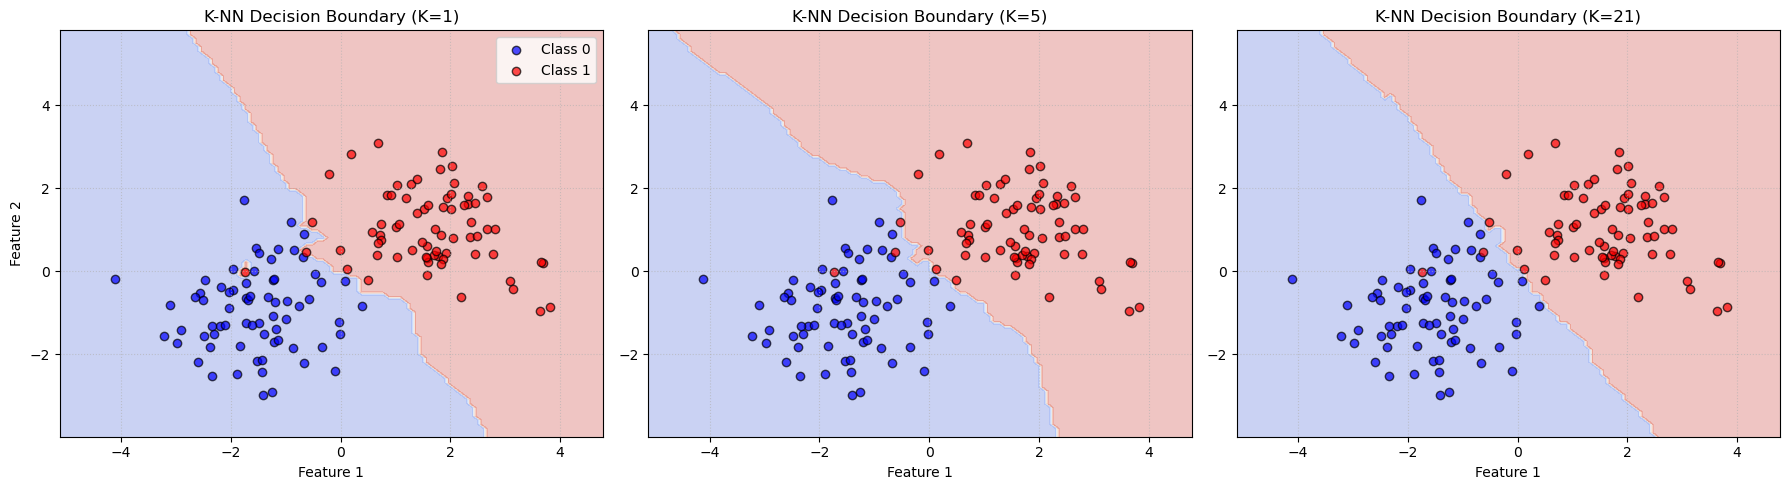

In [7]:
k_boundary_values = [1, 5, 21]

plt.figure(figsize=(18, 5))

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
mesh_points = np.c_[xx.ravel(), yy.ravel()]

for i, k in enumerate(k_boundary_values, 1):
    plt.subplot(1, 3, i)
    
    Z = knn_predict(x_train, y_train, mesh_points, k)
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(x_train[y_train == 0][:, 0], x_train[y_train == 0][:, 1], 
                color='blue', label='Class 0', alpha=0.7, edgecolors='k')
    plt.scatter(x_train[y_train == 1][:, 0], x_train[y_train == 1][:, 1], 
                color='red', label='Class 1', alpha=0.7, edgecolors='k')
    
    plt.title(f'K-NN Decision Boundary (K={k})')
    plt.xlabel('Feature 1')
    if i == 1:
        plt.ylabel('Feature 2')
        plt.legend()
        
    plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Distance-from-means classifier test accuracy: 98.33%


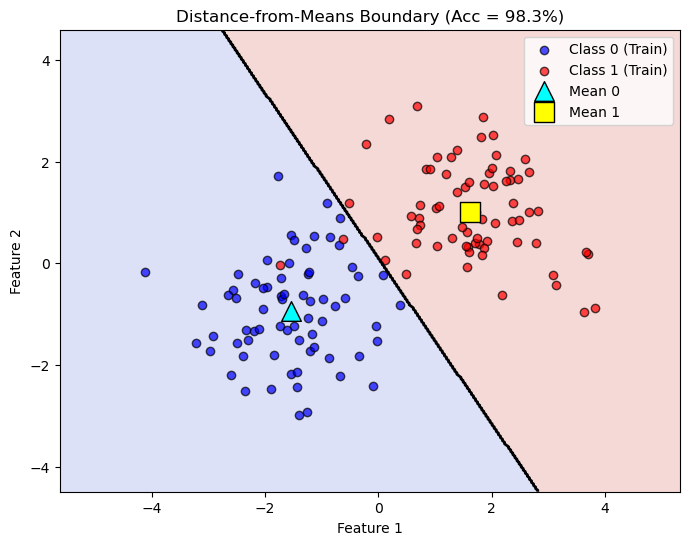

In [8]:
acc_mean = np.mean(y_pred == y_test)
print(f"Distance-from-means classifier test accuracy: {acc_mean*100:.2f}%")

def mean_classifier_predict(P, m0, m1):
    d0 = np.sqrt(((P - m0)**2).sum(axis=1))
    d1 = np.sqrt(((P - m1)**2).sum(axis=1))
    return (d1 < d0).astype(int)

def plot_mean_classifier(x_tr, y_tr, m0, m1, title):
    xx, yy = np.meshgrid(np.linspace(x_tr[:,0].min()-1.5, x_tr[:,0].max()+1.5, 300),
                         np.linspace(x_tr[:,1].min()-1.5, x_tr[:,1].max()+1.5, 300))
    Z = mean_classifier_predict(np.c_[xx.ravel(), yy.ravel()], m0, m1).reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.2, cmap=plt.cm.coolwarm)
    plt.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
    plt.scatter(x_tr[y_tr==0][:,0], x_tr[y_tr==0][:,1], c='blue', edgecolors='k', alpha=0.7, label='Class 0 (Train)')
    plt.scatter(x_tr[y_tr==1][:,0], x_tr[y_tr==1][:,1], c='red',  edgecolors='k', alpha=0.7, label='Class 1 (Train)')
    plt.scatter(*m0, c='cyan',   marker='^', s=200, edgecolors='k', label='Mean 0')
    plt.scatter(*m1, c='yellow', marker='s', s=200, edgecolors='k', label='Mean 1')
    plt.title(title); plt.xlabel('Feature 1'); plt.ylabel('Feature 2'); plt.legend(); plt.show()

plot_mean_classifier(x_train, y_train, mean1_est, mean2_est,
                     f'Distance-from-Means Boundary (Acc = {acc_mean*100:.1f}%)')

In [9]:
np.random.seed(42)
x1b = np.random.multivariate_normal([-1.0, -0.5], np.eye(2), 100)
x2b = np.random.multivariate_normal([ 1.0,  0.5], np.eye(2), 100)
Xb = np.vstack((x1b, x2b))
yb = np.concatenate((np.zeros(100), np.ones(100)))

xb_train, xb_test, yb_train, yb_test = train_test_split(Xb, yb, test_size=0.30, random_state=42)
print(xb_train.shape, xb_test.shape)

(140, 2) (60, 2)


Estimated means: [-1.04734039 -0.43615747] [1.11918651 0.51275567]
Distance-from-means test accuracy (dataset 2): 95.00%


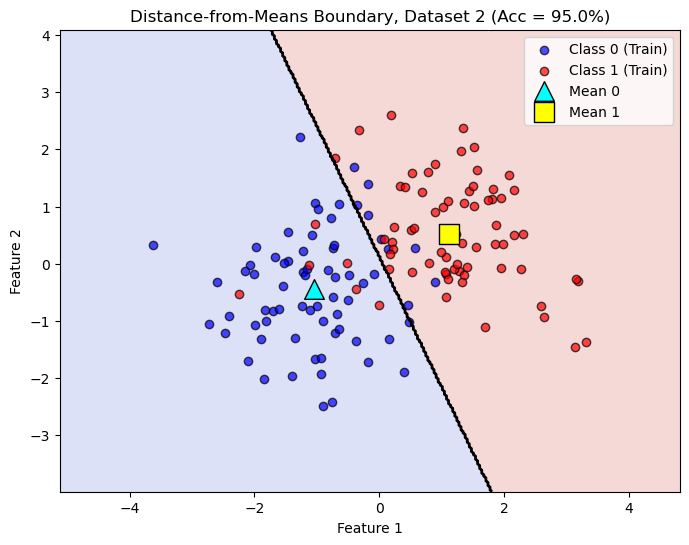

In [10]:
mu0_b = xb_train[yb_train == 0].mean(axis=0)
mu1_b = xb_train[yb_train == 1].mean(axis=0)
print("Estimated means:", mu0_b, mu1_b)

pred_b = mean_classifier_predict(xb_test, mu0_b, mu1_b)
acc_mean_b = np.mean(pred_b == yb_test)
print(f"Distance-from-means test accuracy (dataset 2): {acc_mean_b*100:.2f}%")

plot_mean_classifier(xb_train, yb_train, mu0_b, mu1_b,
                     f'Distance-from-Means Boundary, Dataset 2 (Acc = {acc_mean_b*100:.1f}%)')

K-NN accuracies (dataset 2):
K =  1 | Accuracy = 83.33%
K =  3 | Accuracy = 90.00%
K =  5 | Accuracy = 90.00%
K = 11 | Accuracy = 93.33%
K = 21 | Accuracy = 95.00%


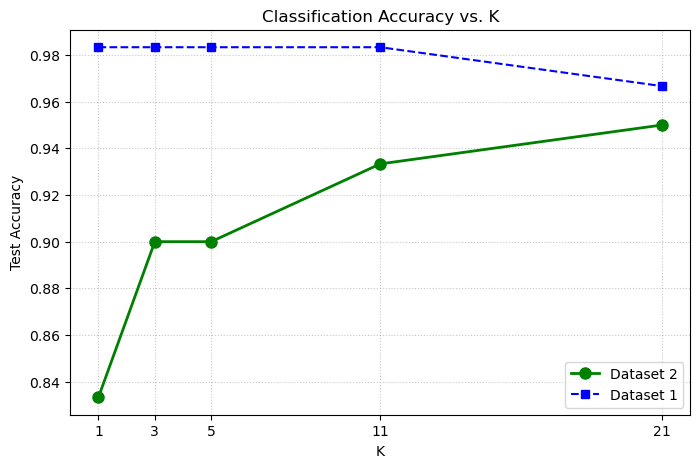

In [11]:
accs_b = []
print("K-NN accuracies (dataset 2):")
for k in k_values:
    p = knn_predict(xb_train, yb_train, xb_test, k)
    a = np.mean(p == yb_test)
    accs_b.append(a)
    print(f"K = {k:2d} | Accuracy = {a*100:.2f}%")

plt.figure(figsize=(8, 5))
plt.plot(k_values, accs_b, marker='o', color='g', linewidth=2, markersize=8, label='Dataset 2')
plt.plot(k_values, accuracies, marker='s', color='b', linestyle='--', label='Dataset 1')
plt.title('Classification Accuracy vs. K'); plt.xlabel('K'); plt.ylabel('Test Accuracy')
plt.xticks(k_values); plt.grid(True, linestyle=':', alpha=0.7); plt.legend(); plt.show()

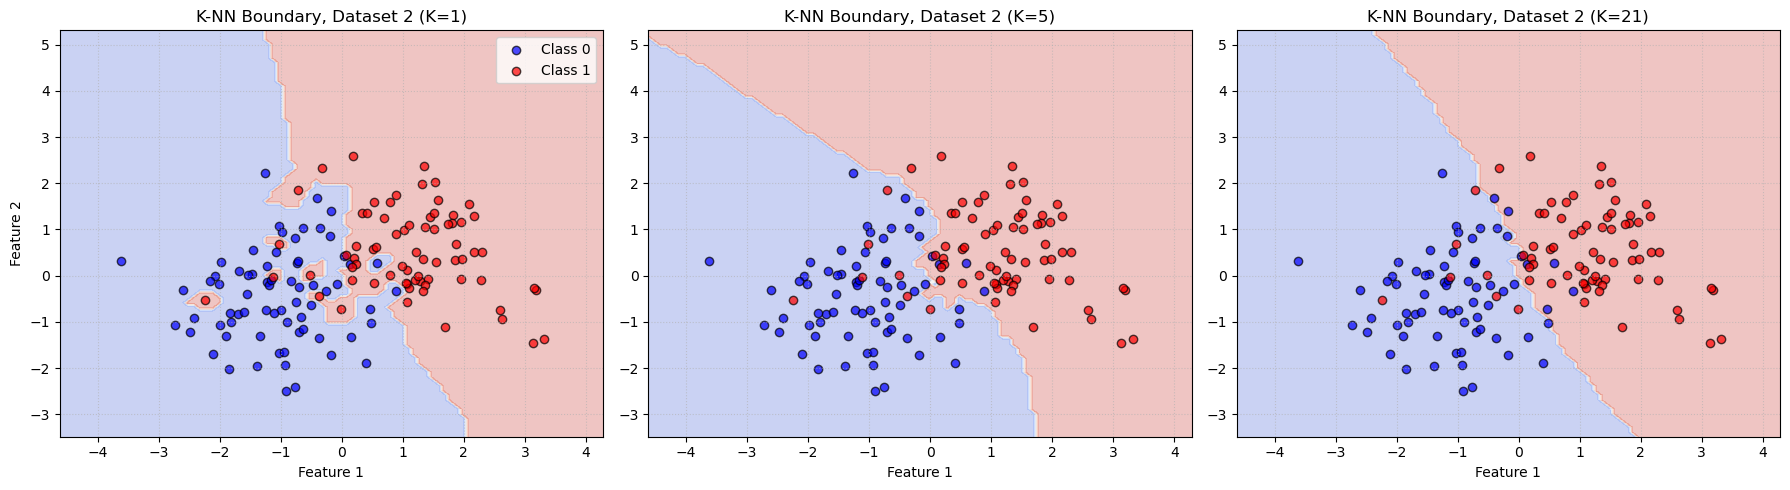

In [12]:
xmin, xmax = Xb[:,0].min()-1, Xb[:,0].max()+1
ymin, ymax = Xb[:,1].min()-1, Xb[:,1].max()+1
xxb, yyb = np.meshgrid(np.arange(xmin, xmax, 0.1), np.arange(ymin, ymax, 0.1))
mesh_b = np.c_[xxb.ravel(), yyb.ravel()]

plt.figure(figsize=(18, 5))
for i, k in enumerate([1, 5, 21], 1):
    plt.subplot(1, 3, i)
    Z = knn_predict(xb_train, yb_train, mesh_b, k).reshape(xxb.shape)
    plt.contourf(xxb, yyb, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(xb_train[yb_train==0][:,0], xb_train[yb_train==0][:,1], c='blue', edgecolors='k', alpha=0.7, label='Class 0')
    plt.scatter(xb_train[yb_train==1][:,0], xb_train[yb_train==1][:,1], c='red',  edgecolors='k', alpha=0.7, label='Class 1')
    plt.title(f'K-NN Boundary, Dataset 2 (K={k})'); plt.xlabel('Feature 1')
    if i == 1: plt.ylabel('Feature 2'); plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout(); plt.show()

 Observations (Task 1 & 2)

- **Dataset 1 (classes far apart):** The mean classifier gave 98.33%. K-NN also gave 98.33% for K = 1, 3, 5, 11, and 96.67% for K = 21. Both methods work very well because the classes are clearly separate.
- **Dataset 2 (classes closer):** The mean classifier gave 95.00%, a small drop. K-NN dropped more: 83.33% (K=1), 90.00% (K=3, 5), 93.33% (K=11) and 95.00% (K=21).
- **Effect of K:** On dataset 2, accuracy increased as K increased. K=1 was the worst because it follows every noisy point, and its boundary was very zigzag. Bigger K gave a smoother boundary and better accuracy.
- **On dataset 1**, K=21 was slightly worse than the smaller K values, so a very big K can also hurt a little.
- **Mean classifier vs K-NN:** On dataset 2, the mean classifier (95%) was as good as the best K-NN (K=21, 95%) and better than small K. The reason is that each class is a round group around its center, so a straight line boundary is enough.

### Difference between Distance-from-Means and K-NN

- The mean classifier finds one mean for each class and gives a new point to the class with the nearest mean. Its boundary is always a straight line.
- K-NN does no training. It stores all the training points, finds the K nearest ones for a new point, and takes a majority vote. Its boundary can be curved.
- The mean classifier is fast and simple. K-NN is more flexible but slower, because it compares with every training point.

## Task 3: K-NN Classification of MNIST

In [14]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X_all = mnist.data
y_all = mnist.target.astype(int)

# standard MNIST split: first 60000 = train, last 10000 = test
X_train_full, y_train_full = X_all[:60000], y_all[:60000]
X_test_full, y_test_full = X_all[60000:], y_all[60000:]

np.random.seed(42)
train_idx = np.random.choice(60000, 10000, replace=False)
test_idx = np.random.choice(10000, 2000, replace=False)

# images are already flattened (784 features); scale pixels to [0, 1]
X_train_m = X_train_full[train_idx].astype(np.float32) / 255.0
y_train_m = y_train_full[train_idx]
X_test_m = X_test_full[test_idx].astype(np.float32) / 255.0
y_test_m = y_test_full[test_idx]

print(f"Tracking - X_train_m shape: {X_train_m.shape}")
print(f"Tracking - X_test_m shape: {X_test_m.shape}")
print(f"Tracking - pixel range: {X_train_m.min()} to {X_train_m.max()}")

Tracking - X_train_m shape: (10000, 784)
Tracking - X_test_m shape: (2000, 784)
Tracking - pixel range: 0.0 to 1.0


In [15]:
def lp_distance(x, X_train, p):
    # distance of one test point x from ALL training points
    # D_p(x, z) = (sum |x_j - z_j|^p)^(1/p)
    return np.sum(np.abs(X_train - x) ** p, axis=1) ** (1 / p)

def knn_predict_mnist(X_train, y_train, X_test, k_list, p):
    # returns a dictionary: {k: predictions}
    preds = {k: [] for k in k_list}
    for test_point in X_test:
        distances = lp_distance(test_point, X_train, p)
        sorted_indices = np.argsort(distances)          # sort once, use for every K
        for k in k_list:
            k_indices = sorted_indices[:k]
            k_nearest_labels = list(y_train[k_indices])
            majority_vote = max(set(k_nearest_labels), key=k_nearest_labels.count)
            preds[k].append(majority_vote)
    return {k: np.array(v) for k, v in preds.items()}

MNIST K-NN Accuracies (Euclidean):
K = 1 | Accuracy = 95.00%
K = 3 | Accuracy = 95.90%
K = 5 | Accuracy = 95.70%
K = 7 | Accuracy = 95.40%
K = 9 | Accuracy = 95.10%

Best K = 3 with accuracy 95.90%


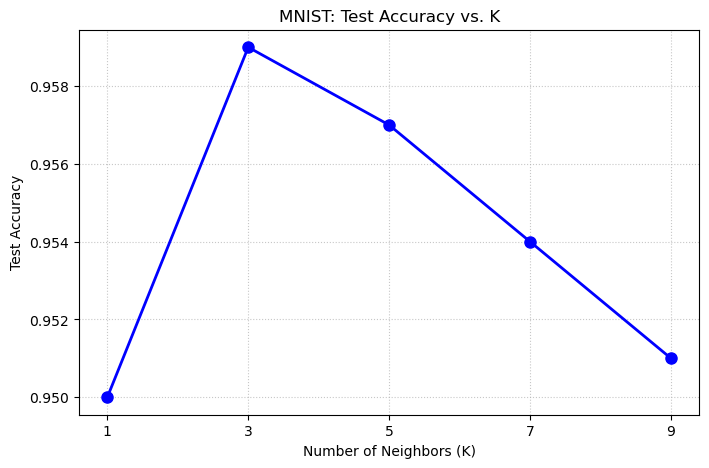

In [16]:
k_values_m = [1, 3, 5, 7, 9]

preds_euc = knn_predict_mnist(X_train_m, y_train_m, X_test_m, k_values_m, p=2)

accuracies_m = []
print("MNIST K-NN Accuracies (Euclidean):")
for k in k_values_m:
    acc = np.mean(preds_euc[k] == y_test_m)
    accuracies_m.append(acc)
    print(f"K = {k} | Accuracy = {acc * 100:.2f}%")

best_k = k_values_m[np.argmax(accuracies_m)]
print(f"\nBest K = {best_k} with accuracy {max(accuracies_m) * 100:.2f}%")

plt.figure(figsize=(8, 5))
plt.plot(k_values_m, accuracies_m, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)
plt.title('MNIST: Test Accuracy vs. K')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Test Accuracy')
plt.xticks(k_values_m)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

In [17]:
preds_man = knn_predict_mnist(X_train_m, y_train_m, X_test_m, [5], p=1)

pred_p1 = preds_man[5]     # Manhattan, K=5
pred_p2 = preds_euc[5]     # Euclidean, K=5

acc_p1 = np.mean(pred_p1 == y_test_m)
acc_p2 = np.mean(pred_p2 == y_test_m)

print("K = 5 Comparison:")
print(f"Manhattan (p=1) Accuracy = {acc_p1 * 100:.2f}%")
print(f"Euclidean (p=2) Accuracy = {acc_p2 * 100:.2f}%")

K = 5 Comparison:
Manhattan (p=1) Accuracy = 94.75%
Euclidean (p=2) Accuracy = 95.70%


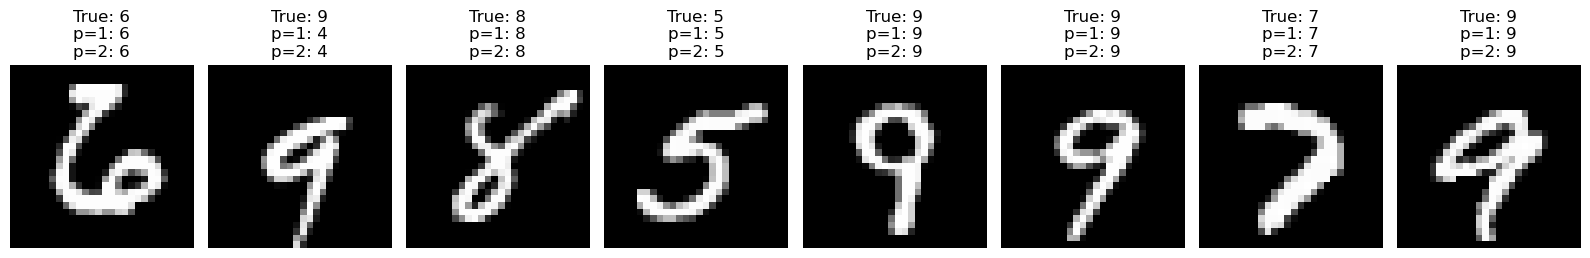

In [18]:
plt.figure(figsize=(16, 3))

for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(X_test_m[i].reshape(28, 28), cmap='gray')
    plt.title(f"True: {y_test_m[i]}\np=1: {pred_p1[i]}\np=2: {pred_p2[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Observations (Task 3)

- K = 3 gave the best accuracy, 95.90%. The other values were close: 95.00% (K=1), 95.70% (K=5), 95.40% (K=7) and 95.10% (K=9). K does not change the result much.
- For K = 5, Euclidean (p=2) gave 95.70% and Manhattan (p=1) gave 94.75%. Euclidean was slightly better, by about 1%.
- In the 8 images shown, p=1 and p=2 gave the same prediction every time. Seven were correct. One "9" was predicted as "4" by both, because it is written in a way that looks like a 4.
- K-NN is simple and gives good accuracy, but it is slow because each test image is compared with all 10,000 training images.